## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/raw/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print("Shape:", df.shape)
print(df.columns.tolist())
df.info()

Shape: (41188, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64

##### Missing values and duplicate records

Here we're checking missing values and duplicate rows that might affect data quality.

In [4]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Duplicate rows: 12


#### Target variable distribution

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_22556\2533451928.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="y", palette="Set2")


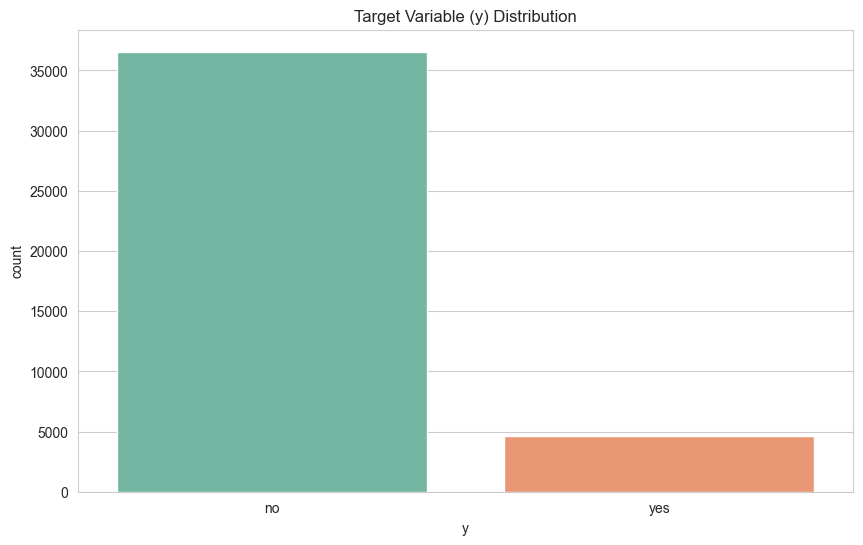

In [5]:
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True) * 100)

sns.countplot(data=df, x="y", palette="Set2")
plt.title("Target Variable (y) Distribution")
plt.show()

##### Here we separate numerical and categorical columns for targeted analysis.

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


##### To check the frequency  of categories to understand it better

In [7]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

--- contact ---


In [8]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Target imbalance is visible, with far more 'no' than 'yes' values.")

Total rows: 41188
Total columns: 21
Target imbalance is visible, with far more 'no' than 'yes' values.


#### Categorical Features vs Target

We compare a few important categorical features with the target variable to identify visible patterns.

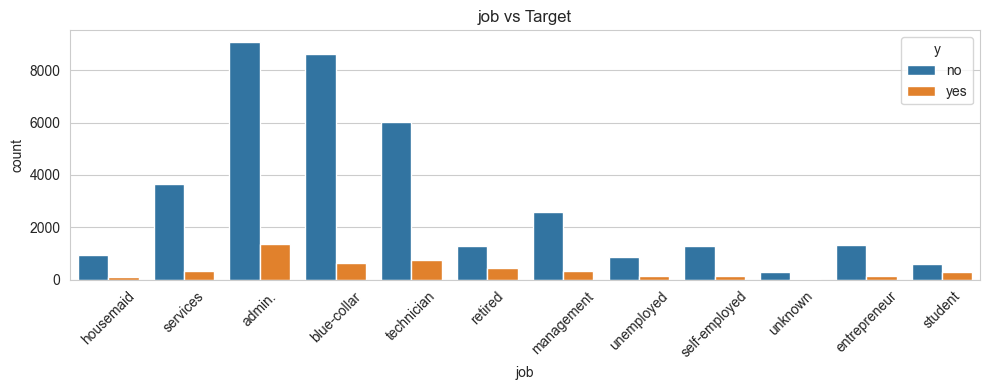

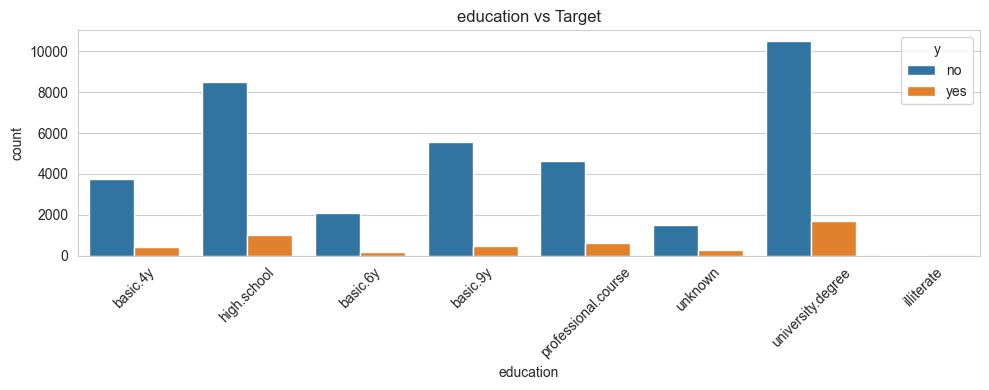

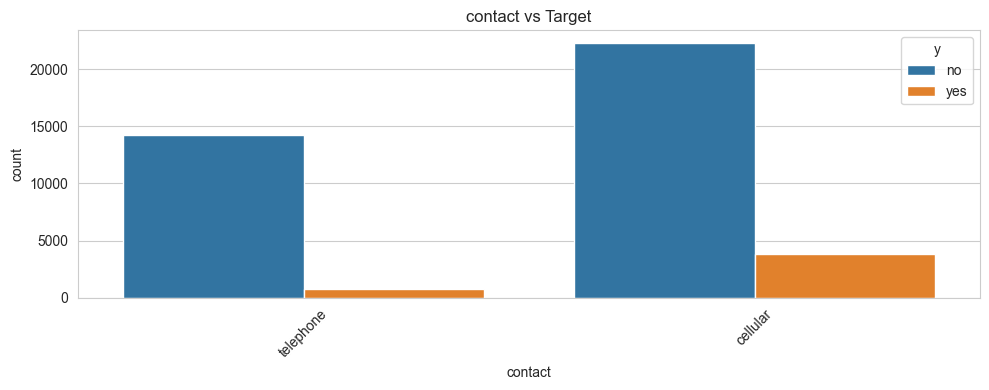

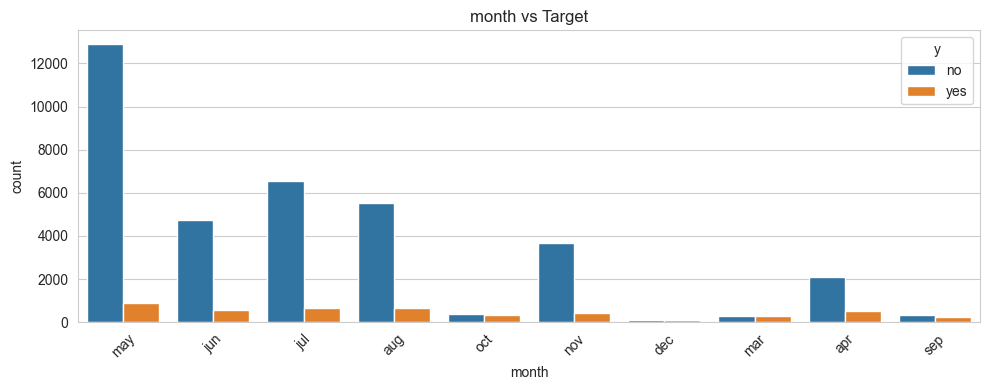

In [9]:
important_cat = ["job", "education", "contact", "month"]

for col in important_cat:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="y")
    plt.title(f"{col} vs Target")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### EDA Observations

The dataset is imbalanced, with a much larger number of 'no' responses than 'yes'.